Vocabulary Size: 23


C:\Users\srish\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


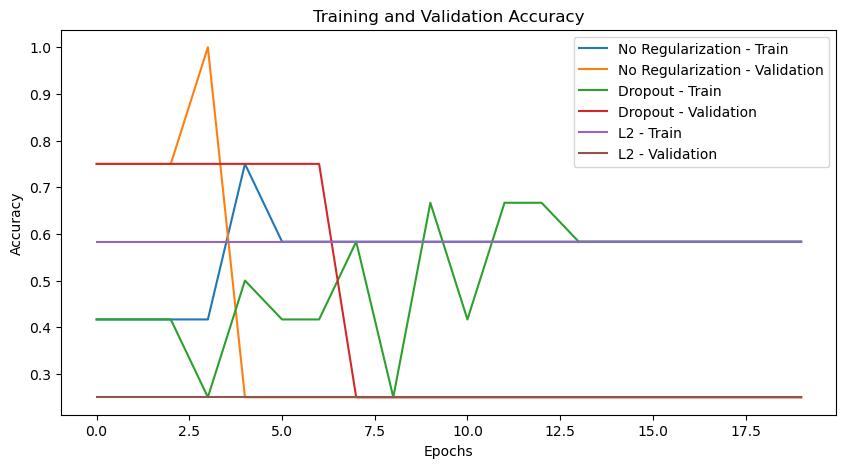

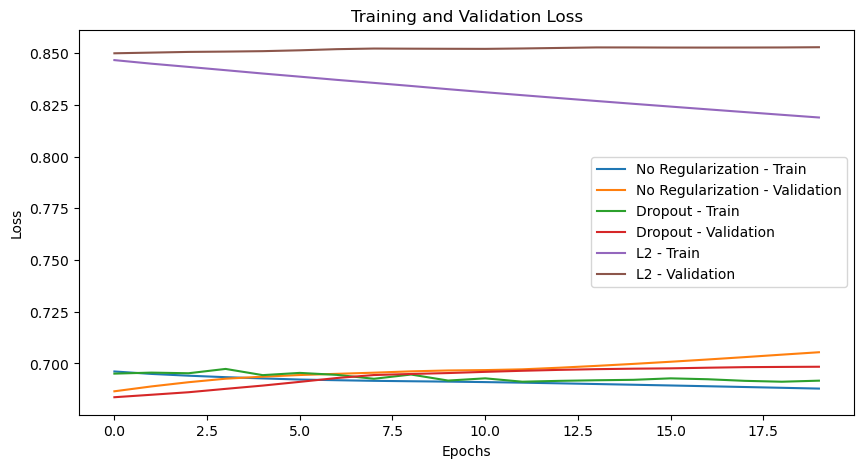


FINAL RESULTS

Without Regularization
Training Accuracy: 0.5833333134651184
Validation Accuracy: 0.25

With Dropout
Training Accuracy: 0.5833333134651184
Validation Accuracy: 0.25

With L2 Regularization
Training Accuracy: 0.5833333134651184
Validation Accuracy: 0.25


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

# -----------------------------
# 1. Dataset
# -----------------------------

texts = [
    "The movie was excellent",
    "I really enjoyed this movie",
    "The story was amazing",
    "The movie was fantastic",
    "I loved the acting",
    "The film was boring",
    "I hated this movie",
    "The story was terrible",
    "The movie was disappointing",
    "The acting was very bad",
    "This was a wonderful film",
    "I enjoyed the excellent story",
    "The film was awful",
    "The movie was not interesting",
    "I really liked this film",
    "The movie was dull"
]

labels = [
    1, 1, 1, 1, 1,
    0, 0, 0, 0, 0,
    1, 1, 0, 0, 1, 0
]

# -----------------------------
# 2. Split Dataset
# -----------------------------

train_texts = texts[:12]
train_labels = np.array(labels[:12])

val_texts = texts[12:]
val_labels = np.array(labels[12:])

# -----------------------------
# 3. Text Vectorization
# -----------------------------

tokenizer = Tokenizer(num_words=1000)
tokenizer.fit_on_texts(train_texts)

X_train = tokenizer.texts_to_sequences(train_texts)
X_val = tokenizer.texts_to_sequences(val_texts)

X_train = pad_sequences(X_train, maxlen=20)
X_val = pad_sequences(X_val, maxlen=20)

vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary Size:", vocab_size)

# -----------------------------
# 4. Create Model
# -----------------------------

def create_model(dropout=False, l2_regularization=False):

    model = Sequential()

    model.add(
        Embedding(
            input_dim=vocab_size,
            output_dim=16,
            input_length=20
        )
    )

    model.add(GlobalAveragePooling1D())

    if l2_regularization:
        model.add(
            Dense(
                16,
                activation="relu",
                kernel_regularizer=l2(0.01)
            )
        )
    else:
        model.add(
            Dense(
                16,
                activation="relu"
            )
        )

    if dropout:
        model.add(Dropout(0.5))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

# -----------------------------
# 5. Without Regularization
# -----------------------------

model1 = create_model()

history1 = model1.fit(
    X_train,
    train_labels,
    validation_data=(X_val, val_labels),
    epochs=20,
    verbose=0
)

# -----------------------------
# 6. With Dropout
# -----------------------------

model2 = create_model(dropout=True)

history2 = model2.fit(
    X_train,
    train_labels,
    validation_data=(X_val, val_labels),
    epochs=20,
    verbose=0
)

# -----------------------------
# 7. With L2 Regularization
# -----------------------------

model3 = create_model(l2_regularization=True)

history3 = model3.fit(
    X_train,
    train_labels,
    validation_data=(X_val, val_labels),
    epochs=20,
    verbose=0
)

# -----------------------------
# 8. Compare Accuracy
# -----------------------------

plt.figure(figsize=(10, 5))

plt.plot(history1.history["accuracy"], label="No Regularization - Train")
plt.plot(history1.history["val_accuracy"], label="No Regularization - Validation")

plt.plot(history2.history["accuracy"], label="Dropout - Train")
plt.plot(history2.history["val_accuracy"], label="Dropout - Validation")

plt.plot(history3.history["accuracy"], label="L2 - Train")
plt.plot(history3.history["val_accuracy"], label="L2 - Validation")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

# -----------------------------
# 9. Compare Loss
# -----------------------------

plt.figure(figsize=(10, 5))

plt.plot(history1.history["loss"], label="No Regularization - Train")
plt.plot(history1.history["val_loss"], label="No Regularization - Validation")

plt.plot(history2.history["loss"], label="Dropout - Train")
plt.plot(history2.history["val_loss"], label="Dropout - Validation")

plt.plot(history3.history["loss"], label="L2 - Train")
plt.plot(history3.history["val_loss"], label="L2 - Validation")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# -----------------------------
# 10. Final Results
# -----------------------------

print("\nFINAL RESULTS")

print("\nWithout Regularization")
print("Training Accuracy:", history1.history["accuracy"][-1])
print("Validation Accuracy:", history1.history["val_accuracy"][-1])

print("\nWith Dropout")
print("Training Accuracy:", history2.history["accuracy"][-1])
print("Validation Accuracy:", history2.history["val_accuracy"][-1])

print("\nWith L2 Regularization")
print("Training Accuracy:", history3.history["accuracy"][-1])
print("Validation Accuracy:", history3.history["val_accuracy"][-1])